# Lab 2 · Keras로 비교하는 MLP(Flatten) / MLP(GAP) / Conv1D

**오늘 배우는 것 (실습 20분)**
- 지난 시간에 저장한 파일을 불러와서 3가지 방식으로 문장을 분류합니다.
  1. **Flatten**: 토큰 임베딩을 한 줄로 펼쳐서 사용
  2. **GAP**: 토큰 임베딩을 평균 내서 사용
  3. **Conv1D**: 주변 단어 패턴(n-gram)을 뽑아서 사용
- 모델마다 각각 **학습곡선 / 정답표(confusion matrix) / t-SNE**를 그려 눈으로 확인합니다.

In [1]:

!pip install -q koreanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib  

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. 저장된 파일 불러오기

In [2]:
data = np.load("data.npz", allow_pickle=True)

ids  = data["input_ids"]
mask = data["attention_mask"]
y    = data["labels"]

idx_tr  = data["train_idx"]
idx_val = data["val_idx"]
idx_te  = data["test_idx"]

vocab_size = int(data["vocab_size"])
max_len    = int(data["max_len"])
n_cls      = int(data["num_classes"])
classes    = data["class_names"].tolist()

X_tr,  M_tr,  y_tr  = ids[idx_tr],  mask[idx_tr],  y[idx_tr]
X_val, M_val, y_val = ids[idx_val], mask[idx_val], y[idx_val]
X_te,  M_te,  y_te  = ids[idx_te],  mask[idx_te],  y[idx_te]

print("train/val/test:", len(X_tr), len(X_val), len(X_te))
print("classes:", classes)

train/val/test: 1680 360 360
classes: ['면접', '학교', '협상']


## 2. 공통 준비물
세 모델이 똑같이 쓸 것들: 임베딩 크기, 학습 설정, PAD 처리, 결과 확인 함수

In [3]:
res = {}  # 모델별 결과를 담아서 성능 비교 노트북에서 씀

import os
if os.path.exists("res.json"):
    os.remove("res.json")  # 이전에 실행했던 낡은 결과가 섞이지 않도록, 시작할 때 한 번 초기화

dim = 64  # 임베딩 크기

def embed(inp, inm):
    """토큰을 벡터로 바꾸고, PAD 자리는 0으로 만든다"""
    x = layers.Embedding(vocab_size, dim)(inp)
    mf = layers.Lambda(lambda t: tf.cast(t, tf.float32)[..., None])(inm)
    return layers.Multiply()([x, mf])

def fit_model(model, name):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    h = model.fit(
        [X_tr, M_tr], y_tr, validation_data=([X_val, M_val], y_val),
        batch_size=32, epochs=20, callbacks=[es], verbose=2,
    )
    return h

In [4]:
def show_result(model, h, name):
    # (1) 학습곡선
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(h.history["loss"], label="train"); ax[0].plot(h.history["val_loss"], label="val")
    ax[0].set_title(f"{name} - Loss"); ax[0].legend()
    ax[1].plot(h.history["accuracy"], label="train"); ax[1].plot(h.history["val_accuracy"], label="val")
    ax[1].set_title(f"{name} - Accuracy"); ax[1].legend()
    plt.tight_layout(); plt.show()

    # (2) 테스트 정확도 + 정답표(confusion matrix)
    pred = model.predict([X_te, M_te], verbose=0).argmax(axis=1)
    acc = (pred == y_te).mean()
    res[name] = {
        "loss": h.history["loss"], "val_loss": h.history["val_loss"],
        "acc": h.history["accuracy"], "val_acc": h.history["val_accuracy"],
        "pred": pred.tolist(), "test_acc": float(acc),
    }
    print(f"[{name}] Test Accuracy: {acc:.3f}")

    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.xticks(range(n_cls), classes); plt.yticks(range(n_cls), classes)
    for i in range(n_cls):
        for j in range(n_cls):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.title(f"{name} - Confusion Matrix"); plt.xlabel("예측"); plt.ylabel("정답")
    plt.tight_layout(); plt.show()

    # (3) t-SNE: 모델이 문장을 어떻게 구분해 놓았는지 2차원으로 확인
    feat_model = keras.Model(model.input, model.get_layer("feat").output)
    feat = feat_model.predict([X_te, M_te], verbose=0)
    xy = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30, n_jobs=1).fit_transform(feat)

    plt.figure(figsize=(5, 5))
    for c in range(n_cls):
        m = y_te == c
        plt.scatter(xy[m, 0], xy[m, 1], s=12, label=classes[c])
    plt.title(f"{name} - t-SNE"); plt.legend()
    plt.tight_layout(); plt.show()

## 3. 모델 1 · Flatten
임베딩을 펼쳐서(Flatten) 완전연결층에 그대로 넣습니다. 가장 단순한 방식입니다.

In [5]:
inp = keras.Input((max_len,), dtype="int32", name="input_ids")
inm = keras.Input((max_len,), dtype="int32", name="attention_mask")

x = embed(inp, inm)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

flat_model = keras.Model([inp, inm], out)
flat_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)        │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_mask (InputLayer)   │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 32, 64)            │       2,048,000 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 32, 1)             │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 32, 64)            │               0 │ embedding[0][0],           │
│                               │                           │                 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 2048)              │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │         131,136 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,180,227 (8.32 MB)

 Trainable params: 2,180,227 (8.32 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
h_flat = fit_model(flat_model, "Flatten")

Epoch 1/20
53/53 - 1s - 20ms/step - accuracy: 0.4494 - loss: 1.0795 - val_accuracy: 0.5528 - val_loss: 1.0184
Epoch 2/20
53/53 - 0s - 6ms/step - accuracy: 0.8012 - loss: 0.6867 - val_accuracy: 0.7139 - val_loss: 0.6379
Epoch 3/20
53/53 - 0s - 6ms/step - accuracy: 0.9637 - loss: 0.1549 - val_accuracy: 0.7556 - val_loss: 0.6151
Epoch 4/20
53/53 - 0s - 5ms/step - accuracy: 0.9988 - loss: 0.0180 - val_accuracy: 0.7750 - val_loss: 0.6068
Epoch 5/20
53/53 - 0s - 5ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.7778 - val_loss: 0.6300
Epoch 6/20
53/53 - 0s - 5ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.7750 - val_loss: 0.6321
Epoch 7/20
53/53 - 0s - 5ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.7722 - val_loss: 0.6415


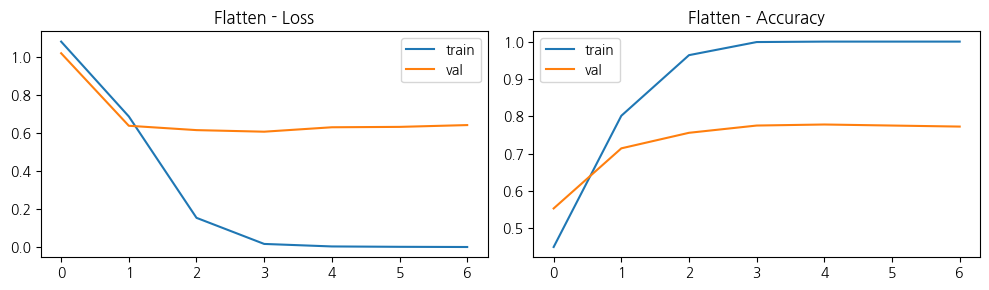

[Flatten] Test Accuracy: 0.811


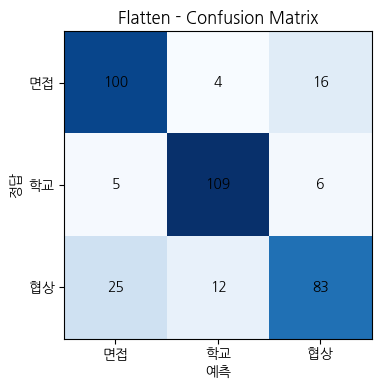

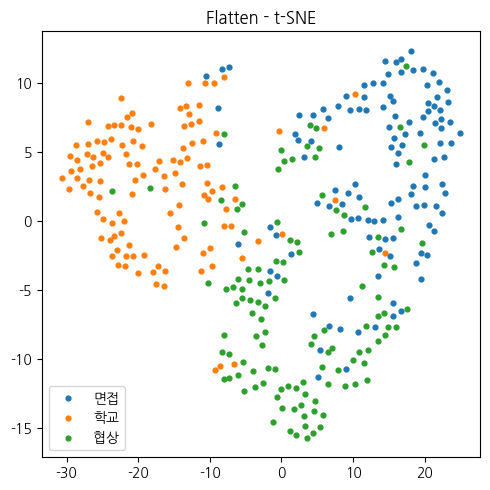

In [7]:
show_result(flat_model, h_flat, "Flatten")

## 4. 모델 2 · GAP (PAD 제외 평균, Masked GAP)
임베딩을 펼치지 않고, **PAD를 제외한 평균**을 냅니다. 문장이 길어도 파라미터 수가 늘지 않습니다.

In [8]:
inp = keras.Input((max_len,), dtype="int32", name="input_ids")
inm = keras.Input((max_len,), dtype="int32", name="attention_mask")

x = embed(inp, inm)
s = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)                 # 시간축으로 합
c = layers.Lambda(lambda m: tf.maximum(                                  # 유효 토큰 수 (PAD 제외)
        tf.reduce_sum(tf.cast(m, tf.float32), axis=1, keepdims=True), 1.0))(inm)
avg = layers.Lambda(lambda t: t[0] / t[1])([s, c])                       # 합 / 유효 토큰 수 = 평균

x = layers.Dense(64, activation="relu")(avg)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

gap_model = keras.Model([inp, inm], out)
gap_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)        │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_mask (InputLayer)   │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 32, 64)            │       2,048,000 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_1 (Lambda)             │ (None, 32, 1)             │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_1 (Multiply)         │ (None, 32, 64)            │               0 │ embedding_1[0][0],         │
│                               │                           │                 │ lambda_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_2 (Lambda)             │ (None, 64)                │               0 │ multiply_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_3 (Lambda)             │ (None, 1)                 │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_4 (Lambda)             │ (None, 64)                │               0 │ lambda_2[0][0],            │
│                               │                           │                 │ lambda_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           4,160 │ lambda_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,053,251 (7.83 MB)

 Trainable params: 2,053,251 (7.83 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
h_gap = fit_model(gap_model, "GAP")

Epoch 1/20
53/53 - 1s - 19ms/step - accuracy: 0.5548 - loss: 1.0797 - val_accuracy: 0.7222 - val_loss: 1.0342
Epoch 2/20
53/53 - 0s - 5ms/step - accuracy: 0.8512 - loss: 0.8176 - val_accuracy: 0.7639 - val_loss: 0.6786
Epoch 3/20
53/53 - 0s - 5ms/step - accuracy: 0.9292 - loss: 0.3305 - val_accuracy: 0.8056 - val_loss: 0.5004
Epoch 4/20
53/53 - 0s - 5ms/step - accuracy: 0.9685 - loss: 0.1246 - val_accuracy: 0.8139 - val_loss: 0.4956
Epoch 5/20
53/53 - 0s - 6ms/step - accuracy: 0.9923 - loss: 0.0531 - val_accuracy: 0.8000 - val_loss: 0.5225
Epoch 6/20
53/53 - 0s - 5ms/step - accuracy: 0.9982 - loss: 0.0250 - val_accuracy: 0.8000 - val_loss: 0.5719
Epoch 7/20
53/53 - 0s - 5ms/step - accuracy: 0.9988 - loss: 0.0140 - val_accuracy: 0.7889 - val_loss: 0.6123


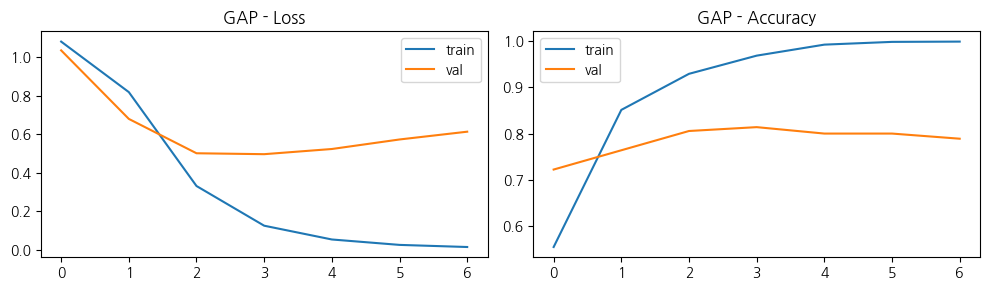

[GAP] Test Accuracy: 0.856


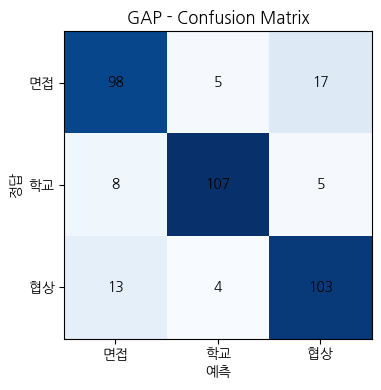

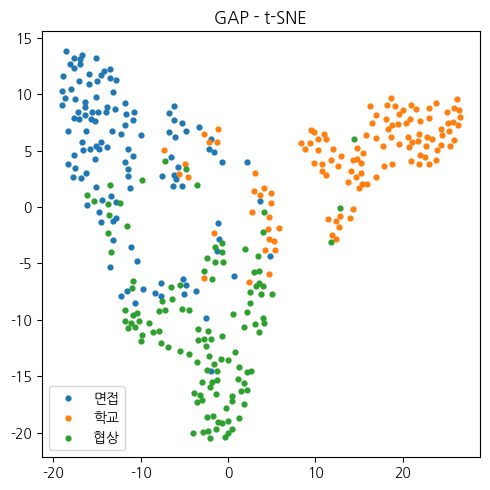

In [10]:
show_result(gap_model, h_gap, "GAP")

## 5. 모델 3 · Conv1D
주변 단어 3개씩(kernel_size=3)을 보면서 패턴을 찾고, 가장 강하게 반응한 부분만 골라냅니다(Max Pooling).

In [11]:
inp = keras.Input((max_len,), dtype="int32", name="input_ids")
inm = keras.Input((max_len,), dtype="int32", name="attention_mask")

x = embed(inp, inm)
x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)

# PAD 위치가 Max Pooling에서 뽑히지 않도록 아주 작은 값으로 밀어냄
bias = layers.Lambda(lambda m: (1.0 - tf.cast(m, tf.float32))[..., None] * -1e9)(inm)
x = layers.Add()([x, bias])
x = layers.GlobalMaxPooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

conv_model = keras.Model([inp, inm], out)
conv_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)        │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_mask (InputLayer)   │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 32, 64)            │       2,048,000 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_5 (Lambda)             │ (None, 32, 1)             │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_2 (Multiply)         │ (None, 32, 64)            │               0 │ embedding_2[0][0],         │
│                               │                           │                 │ lambda_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 32, 64)            │          12,352 │ multiply_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_6 (Lambda)             │ (None, 32, 1)             │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 64)            │               0 │ conv1d[0][0],              │
│                               │                           │                 │ lambda_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 64)                │               0 │ add[0][0]                  │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           4,160 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,065,603 (7.88 MB)

 Trainable params: 2,065,603 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
h_conv = fit_model(conv_model, "Conv1D")

Epoch 1/20
53/53 - 1s - 25ms/step - accuracy: 0.4827 - loss: 1.0630 - val_accuracy: 0.5778 - val_loss: 0.9798
Epoch 2/20
53/53 - 0s - 6ms/step - accuracy: 0.7405 - loss: 0.7246 - val_accuracy: 0.7083 - val_loss: 0.6810
Epoch 3/20
53/53 - 0s - 6ms/step - accuracy: 0.9000 - loss: 0.3544 - val_accuracy: 0.7806 - val_loss: 0.5461
Epoch 4/20
53/53 - 0s - 6ms/step - accuracy: 0.9780 - loss: 0.0991 - val_accuracy: 0.7861 - val_loss: 0.5340
Epoch 5/20
53/53 - 0s - 6ms/step - accuracy: 0.9982 - loss: 0.0220 - val_accuracy: 0.8000 - val_loss: 0.5183
Epoch 6/20
53/53 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.8000 - val_loss: 0.5492
Epoch 7/20
53/53 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8028 - val_loss: 0.5679
Epoch 8/20
53/53 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8000 - val_loss: 0.5704


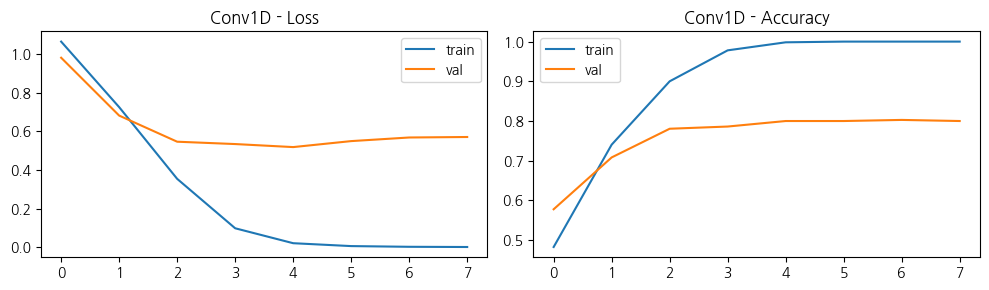

[Conv1D] Test Accuracy: 0.858


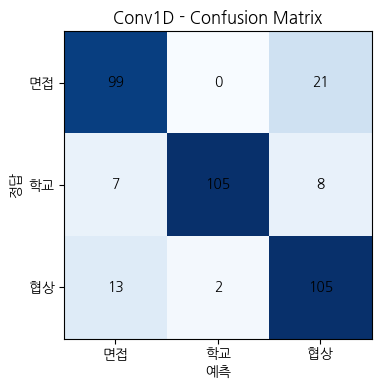

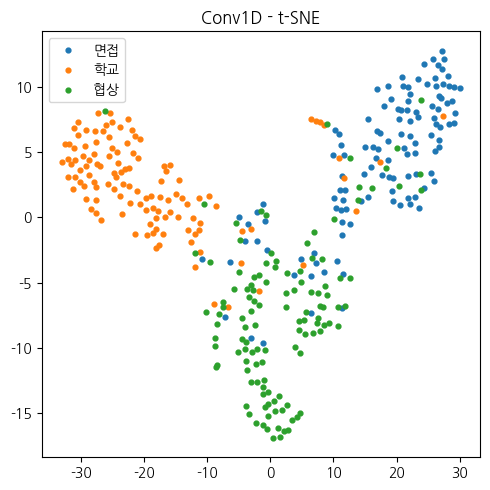

In [13]:
show_result(conv_model, h_conv, "Conv1D")

## 결과 저장 (성능 비교 노트북용)

In [14]:
# 결과 저장 (성능 비교 노트북용)
import json, os

path = "res.json"
old = json.load(open(path, encoding="utf-8")) if os.path.exists(path) else {}
old.update(res)
json.dump(old, open(path, "w", encoding="utf-8"), ensure_ascii=False)

print("저장된 모델:", list(old.keys()))


저장된 모델: ['Flatten', 'GAP', 'Conv1D']


## 정리

| 모델 | 핵심 아이디어 | Test Accuracy |
|---|---|---|
| Flatten | 임베딩을 펼쳐서 그대로 사용 | 0.811 |
| GAP | PAD 제외 평균 | 0.858 |
| Conv1D | 주변 단어 패턴 + Max Pooling | 0.861 |

파라미터가 가장 많은 Flatten이 오히려 가장 낮은 정확도를 보였습니다. 2,400문장이라는 작은 데이터에서는 "단순하고 가벼운" 구조(GAP)나 "지역 패턴만 뽑는" 구조(Conv1D)가 더 안정적으로 학습된다는 걸 확인할 수 있습니다.

> **주의:** 세 모델은 같은 데이터·같은 학습 설정을 쓰지만 파라미터 수는 서로 다릅니다(특히 Flatten은 `MAX_LEN`에 비례해 파라미터가 늘어남). 그래서 이 결과는 "어떤 구조가 절대적으로 더 우수하다"는 증명이 아니라, **같은 조건에서 처리 방식에 따라 결과가 어떻게 달라지는지 관찰**한 것으로 해석하는 게 정확합니다.

다음 실습(Lab 3)에서는 같은 데이터로 **SimpleRNN / LSTM / GRU**를 학습시켜 봅니다.
